In [12]:
#Part a) EDA
# i)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path="penguins.csv"
df = pd.read_csv(data_path)

print (f"Shape: {df.shape}")
print (f"Data types:\n{df.dtypes}")
print ("\n ================= Describe =================\n")
print(df.describe())



Shape: (344, 8)
Data types:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object

 ================= Describe =================

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.300000         197.000000  4050.000000   
75%         48.500000      18.700000         213.000000  4750.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   

In [13]:
print (f"Adelie Penguings: {df['species'].value_counts()['Adelie']}")
print (f"Gentoo Penguings: {df['species'].value_counts()['Gentoo']}")
print (f"Chinstrap Penguings: {df['species'].value_counts()['Chinstrap']}\n")

print(f"Penguings in Torgersen: {df['island'].value_counts()['Torgersen']}")
print(f"Penguings in Biscoe: {df['island'].value_counts()['Biscoe']}")
print(f"Penguings in Dream: {df['island'].value_counts()['Dream']}")



Adelie Penguings: 152
Gentoo Penguings: 124
Chinstrap Penguings: 68

Penguings in Torgersen: 52
Penguings in Biscoe: 168
Penguings in Dream: 124


In [14]:
# ii)
missing_values = []
for column in df.columns:
    missing_values.append(df[column].isna().sum())
    print(f"Missing values in {column}: {missing_values[-1]}")

morphological_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_cleaned = df.dropna(subset=morphological_features)
print(f"\nRemaning Penguins after removing missing data: {len(df_cleaned)}")


Missing values in species: 0
Missing values in island: 0
Missing values in bill_length_mm: 2
Missing values in bill_depth_mm: 2
Missing values in flipper_length_mm: 2
Missing values in body_mass_g: 2
Missing values in sex: 11
Missing values in year: 0

Remaning Penguins after removing missing data: 342


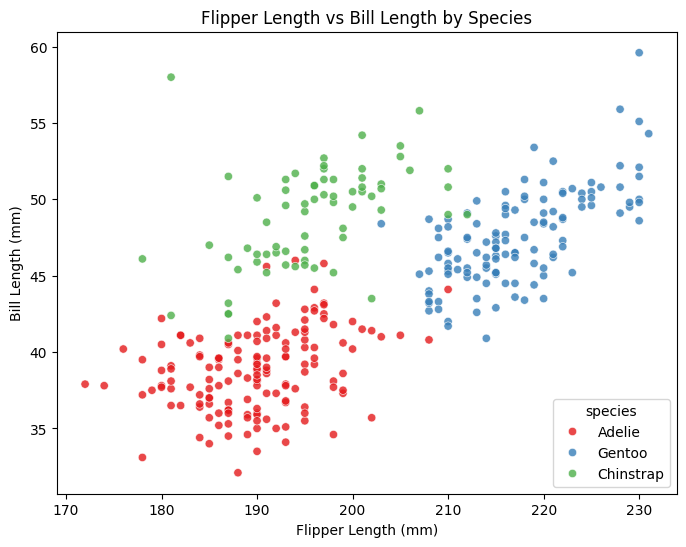

In [15]:
# iii)
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df, 
    x='flipper_length_mm', 
    y='bill_length_mm', 
    hue='species',
    palette='Set1',
    alpha=0.8
)

plt.title("Flipper Length vs Bill Length by Species")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Bill Length (mm)")

# Show the plot
plt.show()

There are 3 clearly defined blobs. However, Adelie and Chinstrap are somewhat similar and have overlaping points.

In [23]:
# b)
# i)
df_morphological = df_cleaned[morphological_features]
print (f"New shape {df_morphological.shape}")

New shape (342, 4)


ii) Standardizing the data is very important for the computation of Euclidian distance. If the unit of measurement are very different, different features will not be comparable since the ones with larger numbers will completely dominate the computation making our algorithm essentially ignore features with small numbers.

In [24]:
# iii)
df_standardized = df_morphological.copy()

for feature in morphological_features:
    mean_val = df[feature].mean()
    std_val = df[feature].std()
    
    # z = (x - µ) / σ
    df_standardized[feature] = (df[feature] - mean_val) / std_val

print("=== After Standardization ===")
for feature in morphological_features:
    post_mean = df_standardized[feature].mean()
    post_std = df_standardized[feature].std()
    print(f"{feature}:")
    print(f"  Resulting Mean: {post_mean:.6f}")
    print(f"  Resulting Std Dev: {post_std:.6f}\n")
    print(f"  Number of NaN values: {df_standardized[feature].isna().sum()}")

=== After Standardization ===
bill_length_mm:
  Resulting Mean: 0.000000
  Resulting Std Dev: 1.000000

  Number of NaN values: 0
bill_depth_mm:
  Resulting Mean: 0.000000
  Resulting Std Dev: 1.000000

  Number of NaN values: 0
flipper_length_mm:
  Resulting Mean: -0.000000
  Resulting Std Dev: 1.000000

  Number of NaN values: 0
body_mass_g:
  Resulting Mean: 0.000000
  Resulting Std Dev: 1.000000

  Number of NaN values: 0


Final Inertia (J): 378.2832


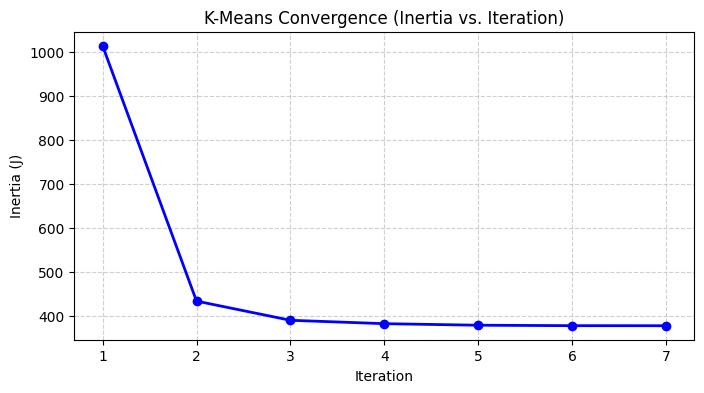

In [28]:
def kmeans(X, k, max_iter=100, seed=0):
    X = np.asarray(X)
    N, D = X.shape
    
    # Initialization
    np.random.seed(seed)
    initial_indices = np.random.choice(N, size=k, replace=False)
    centroids = X[initial_indices].copy()
    
    labels = np.full(N, -1)
    loss_history = []  # To track inertia at each iteration
    
    for iteration in range(max_iter):
        # 1. Assignment Step
        distances = np.sum((X[:, np.newaxis] - centroids) ** 2, axis=2)
        new_labels = np.argmin(distances, axis=1)
        
        # Calculate inertia for this step and save to history
        inertia = np.sum(np.min(distances, axis=1))
        loss_history.append(inertia)
        
        # 2. Convergence Check
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        
        # 3. Update Step
        for c in range(k):
            cluster_points = X[labels == c]
            if len(cluster_points) > 0:
                centroids[c] = cluster_points.mean(axis=0)
                
    return centroids, labels, loss_history[-1], loss_history

X_penguins = df_standardized[morphological_features].values
centroids, labels, final_inertia, loss_history = kmeans(X_penguins, k=3, seed=42)

print(f"Final Inertia (J): {final_inertia:.4f}")
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', color='b', linewidth=2)
plt.title("K-Means Convergence (Inertia vs. Iteration)")
plt.xlabel("Iteration")
plt.ylabel("Inertia (J)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, len(loss_history) + 1))
plt.show()